<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/Melbourne-housing-DTA/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
RAW_URL = "https://raw.githubusercontent.com/NatalieAleksandrova2026/Melbourne-housing-DTA/refs/heads/main/data/melb_data.csv"
df = pd.read_csv(RAW_URL)
df_origin = df.copy()

In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
df.shape

(13580, 21)

In [5]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Коротке резюме проблем для фіксації в нотатках:
Технічні дублі: Перевірити взаємозв'язок між Rooms та Bedroom2 (в останньому є викид у 20 спалень).

Зміна типів даних: Перевести Postcode з числового типу в текстовий/категоріальний.

Критичні пропуски: BuildingArea (47.5%) та YearBuilt (39.6%) потребують стратегії відновлення даних.

Очищення від аномалій: * Видалити або виправити рік побудови 1196.

Обробити нульові значення в Landsize та BuildingArea.

Дослідити гігантські максимуми в площах (Landsize = 433k, BuildingArea = 44k).

In [6]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [8]:
df = df.loc[:, ~df.columns.str.match(r'^Unnamed')]

In [9]:
df['Postcode'] = df['Postcode'].astype('string')

In [10]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,string[python]


`df.isna()` позначає порожні клітинки; `df.isna().sum()` рахує їх по стовпцях, а `df.isna().mean()` дає частку (від 0 до 1, помножте на 100 для відсотків).

In [11]:
df.isna()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13576,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
13577,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13578,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [12]:
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [13]:
missing = (df.isna().mean() * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

BuildingArea    47.5
YearBuilt       39.6
CouncilArea     10.1
Car              0.5
dtype: float64


In [14]:
df.describe()

,Rooms,Price,Date,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,2017-01-28 20:25:03.622974976,10.137776,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,2016-09-10 00:00:00,6.100000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,2017-03-04 00:00:00,9.200000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,2017-06-24 00:00:00,13.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,2017-09-23 00:00:00,48.100000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000
std,0.955748,6.393107e+05,NaN,5.868725,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772


In [15]:
print(df[df['Landsize'] > 10000])
print(df[df['BuildingArea'] > 1000])
print(df[df['YearBuilt'] < 1800])

               Suburb                  Address  Rooms Type      Price Method        SellerG       Date  Distance  \
687      Balwyn North              9 Gildan St      3    h  2000000.0     VB            Kay 2016-08-28       9.2   
2084      Collingwood          4/170 Oxford St      3    u   950000.0      S         Jellis 2017-03-04       1.6   
2487   Essendon North              1 Dudley St      3    h  1425000.0      S        McGrath 2017-02-25       9.4   
3750        Maidstone      17/46 Eucalyptus Dr      2    u   352500.0      S  hockingstuart 2017-03-18       9.2   
3942      Maribyrnong          44/2 Horizon Dr      2    u   495000.0      S           Brad 2017-03-18       8.7   
4706   Port Melbourne          36/3 Seisman Pl      2    u  1340000.0     VB       Chisholm 2016-12-03       3.8   
5194        Reservoir             14 Beenak St      3    h   572000.0      S            Ray 2016-04-23      11.2   
5584      South Yarra        413/35 Malcolm St      1    u   315000.0   

In [16]:
df.loc[df['Landsize'] == 0, 'Landsize'] = np.nan
df.loc[df['BuildingArea'] == 0, 'BuildingArea'] = np.nan

In [17]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,string[python]


In [18]:
df.loc[df["YearBuilt"] < 1800, "YearBuilt"] = np.nan

In [19]:
print(df.duplicated().sum())

0


In [20]:
df.shape

(13580, 21)

### Крок 4. Дослідження (EDA)

- **гістограма** показує, як розподілені значення. Для ціни вона зазвичай "скошена" - багато дешевих об'єктів і довгий хвіст дорогих. Якщо взяти логарифм ціни, картинка стає рівнішою.

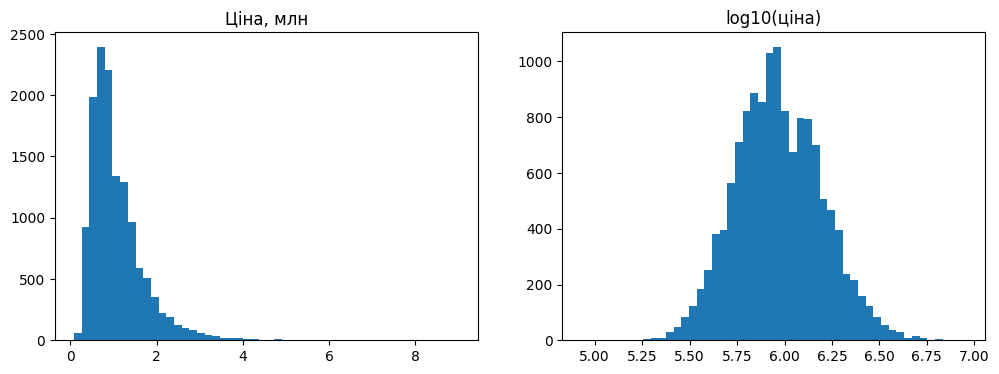

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["Price"] / 1e6, bins=50)
ax[0].set_title("Ціна, млн")

ax[1].hist(np.log10(df["Price"]), bins=50)
ax[1].set_title("log10(ціна)")

plt.show()

**boxplot за категорією** (наприклад, за типом житла) показує, де ціни вищі, а де нижчі.

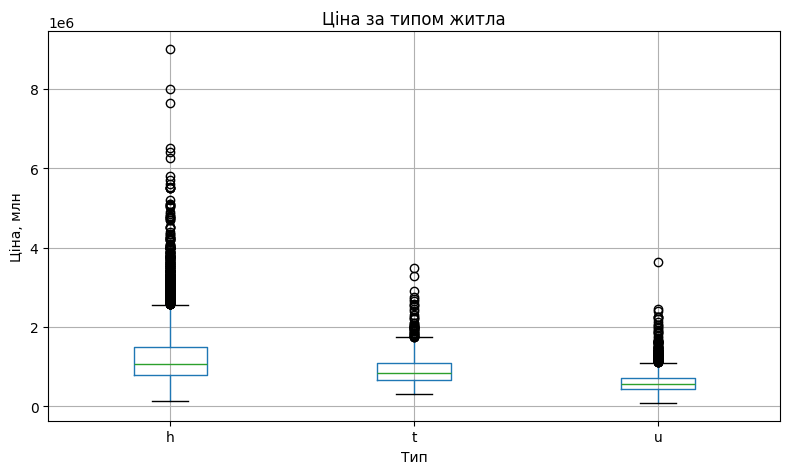

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='Price', by='Type', ax=ax)

ax.set_title('Ціна за типом житла')
ax.set_xlabel('Тип')
ax.set_ylabel('Ціна, млн')
plt.suptitle('')
plt.tight_layout()
plt.show()

Про **кореляцію** докладніше, бо це важливий інструмент аналітика:
- Знак: `+` означає "разом зростають", `-` означає "коли одне більше, інше менше".
- Сила: чим ближче число до 1 або -1, тим сильніший лінійний зв'язок; близько 0 - зв'язку майже немає. Грубі орієнтири: понад 0.5 - помітний, 0.3-0.5 - помірний, менше 0.2 - слабкий.
- Навіщо: так ви бачите, які ознаки пов'язані з ціною (кандидати у важливі), і знаходите майже однакові ознаки (їх не варто тримати разом).
- Важливо: кореляція бачить лише **лінійні** зв'язки і **не означає причинність**.

In [23]:
num = df.select_dtypes('number')
corr_price = num.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)
print(corr_price.round(2))

Rooms            0.50
Bedroom2         0.48
Bathroom         0.47
YearBuilt       -0.33
Car              0.24
Lattitude       -0.21
Longtitude       0.20
Distance        -0.16
BuildingArea     0.09
Propertycount   -0.04
Landsize         0.02
Name: Price, dtype: float64


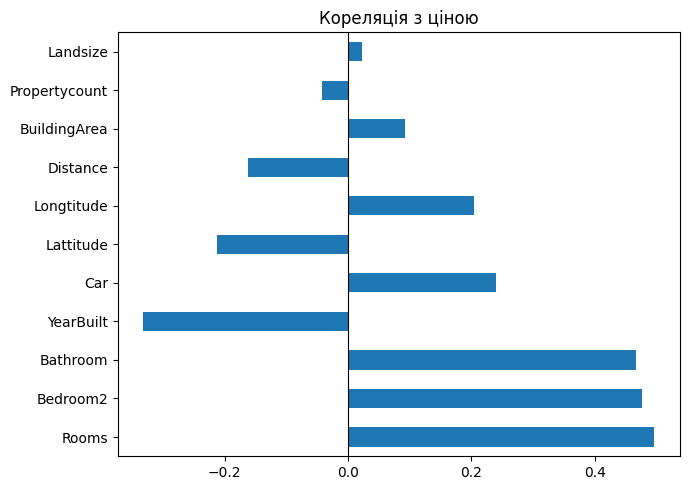

In [24]:
corr_price.plot(kind='barh', figsize=(7, 5), title='Кореляція з ціною')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Найсильніше з ціною пов'язані розмір житла — Rooms (0.50), Bedroom2 (0.48), Bathroom (0.47). Це одна група ознак, яка описує одне й те саме: чим більше житло, тим воно дорожче.
На другому місці — вік будинку: YearBuilt (−0.33). Знак від'ємний — старіші будинки дорожчі. Для Мельбурна це характерно: вікторіанські будинки у внутрішніх районах є преміальним товаром.
Локація (Lattitude −0.21, Longtitude 0.20, Distance −0.16) — помірний вплив. Від'ємна кореляція з Distance підтверджує: ближче до центру = дорожче.
Площа (BuildingArea 0.09, Landsize 0.02) — майже не впливає як лінійна ознака. Це не означає, що площа неважлива — просто лінійна кореляція її не вловлює через викиди і пропуски.

пошук майже-дублікатів: подивіться на повну матрицю кореляцій  
- num.corr() (можна .round(2))
- знайдіть пари з дуже високим зв'язком (наприклад, Rooms і Bedroom2)

In [25]:
print(num.corr().round(2))


               Rooms  Price  Distance  Bedroom2  Bathroom   Car  Landsize  BuildingArea  YearBuilt  Lattitude  \
Rooms           1.00   0.50      0.29      0.94      0.59  0.41      0.00          0.12      -0.07       0.02   
Price           0.50   1.00     -0.16      0.48      0.47  0.24      0.02          0.09      -0.33      -0.21   
Distance        0.29  -0.16      1.00      0.30      0.13  0.26      0.01          0.10       0.25      -0.13   
Bedroom2        0.94   0.48      0.30      1.00      0.58  0.41      0.00          0.12      -0.05       0.02   
Bathroom        0.59   0.47      0.13      0.58      1.00  0.32      0.03          0.11       0.15      -0.07   
Car             0.41   0.24      0.26      0.41      0.32  1.00      0.02          0.10       0.11      -0.00   
Landsize        0.00   0.02      0.01      0.00      0.03  0.02      1.00          0.50       0.08       0.01   
BuildingArea    0.12   0.09      0.10      0.12      0.11  0.10      0.50          1.00       0.

Після графіків і чисел **запишіть словами** 2-3 висновки: який тип житла дорожчий, як впливає відстань, які ознаки майже дублюються.

1. Rooms і Bedroom2 — майже одне й те саме.

Кореляція 0.94 — це майже повний дублікат. Обидві ознаки описують розмір житла, але Bedroom2 ще й має більше пропусків. У моделі залишаємо лише Rooms, Bedroom2 прибираємо.
2. Відстань від центру впливає на ціну слабше, ніж очікувалось.

Distance ↔ Price = −0.16 — зв'язок є і знак правильний (далі = дешевше), але він помірний. Цікаво, що Distance краще корелює з Rooms (0.29) — у передмістях будинки більші, але не обов'язково дорожчі.
3. Landsize і BuildingArea не впливають на ціну, але пов'язані між собою.

Landsize ↔ Price = 0.02 — нуль. BuildingArea ↔ Price = 0.09 — майже нуль. Зате Landsize ↔ BuildingArea = 0.50 — помірний зв'язок між собою. Площа ділянки і площа забудови без урахування локації ціну не пояснюють — у центрі маленька квартира коштує більше ніж великий будинок на околиці.You've used 90% of your session limitUpgrade

1. Rooms і Bedroom2 — майже одне й те саме.

Кореляція 0.94 — це майже повний дублікат. Обидві ознаки описують розмір житла, але Bedroom2 ще й має більше пропусків. У моделі залишаємо лише Rooms, Bedroom2 прибираємо.
2. Відстань від центру впливає на ціну слабше, ніж очікувалось.

Distance ↔ Price = −0.16 — зв'язок є і знак правильний (далі = дешевше), але він помірний. Цікаво, що Distance краще корелює з Rooms (0.29) — у передмістях будинки більші, але не обов'язково дорожчі.
3. Landsize і BuildingArea не впливають на ціну, але пов'язані між собою.

Landsize ↔ Price = 0.02 — нуль. BuildingArea ↔ Price = 0.09 — майже нуль. Зате Landsize ↔ BuildingArea = 0.50 — помірний зв'язок між собою. Площа ділянки і площа забудови без урахування локації ціну не пояснюють — у центрі маленька квартира коштує більше ніж великий будинок на околиці.  
Найважливіше: ознака не повинна "підглядати" у ціль. "Ціна за кімнату" рахується з `Price`, якої в реальному прогнозі ще немає - це помилка (витік).


```python
fe = clean.copy()

1) частини дати продажу
- рік: fe["sale_year"] = fe["Date"].dt.year
- місяць: за аналогією дістаньте .dt.month

In [26]:
fe = df.copy()

fe['sale_year'] = fe['Date'].dt.year
fe['sale_month'] = fe['Date'].dt.month

print(fe[['Date', 'sale_year', 'sale_month']].head())

        Date  sale_year  sale_month
0 2016-12-03       2016          12
1 2016-02-04       2016           2
2 2017-03-04       2017           3
3 2017-03-04       2017           3
4 2016-06-04       2016           6


 2) вік будинку на момент продажу
- це рік продажу мінус рік побудови (YearBuilt)
- підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan

**вік будинку** = рік продажу мінус рік побудови. Часто важливіший за сам рік побудови.

In [27]:
fe['house_age'] = fe['sale_year'] - fe['YearBuilt']

fe.loc[fe['house_age'] < 0, 'house_age'] = np.nan

print(fe['house_age'].describe().round(1))

count    8198.0
mean       51.8
std        36.2
min         0.0
25%        18.0
50%        47.0
75%        76.0
max       186.0
Name: house_age, dtype: float64


- **прапорець наявності** - новий стовпець 0/1: чи було значення (1) чи був пропуск (0). Іноді сам факт пропуску щось означає.

In [28]:
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
# Створюємо прапорець для BuildingArea
fe['has_buildingarea'] = fe['BuildingArea'].notna().astype(int)

# Створюємо такий самий прапорець для YearBuilt
fe['has_yearbuilt'] = fe['YearBuilt'].notna().astype(int)

# Перевіримо, як це виглядає (виведемо оригінальні стовпці та нові прапорці)
print(fe[['BuildingArea', 'has_buildingarea', 'YearBuilt', 'has_yearbuilt']].head())

   BuildingArea  has_buildingarea  YearBuilt  has_yearbuilt
0           NaN                 0        NaN              0
1          79.0                 1     1900.0              1
2         150.0                 1     1900.0              1
3           NaN                 0        NaN              0
4         142.0                 1     2014.0              1


- **частотне кодування** району: замість сотень стовпців на кожен район - один стовпець із тим, як часто цей район трапляється.

In [29]:
# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

print(fe[['Suburb', 'suburb_freq']].head(10))

       Suburb  suburb_freq
0  Abbotsford           56
1  Abbotsford           56
2  Abbotsford           56
3  Abbotsford           56
4  Abbotsford           56
5  Abbotsford           56
6  Abbotsford           56
7  Abbotsford           56
8  Abbotsford           56
9  Abbotsford           56


In [30]:
#5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
# Визначаємо список стовпців, які потрібно видалити
columns_to_drop = [
    'Bedroom2',   # Дубль стовпця Rooms з аномаліями
    'Address',    # Унікальний текст (забагато категорій)
    'SellerG',    # Текст, який ми не кодуємо
    'Suburb',     # Видаляємо оригінал, бо вже зробили suburb_freq
    'CouncilArea' # Багато пропусків і тексту, залишаємо Regionname
]

# Видаляємо їх з копії fe
fe = fe.drop(columns=columns_to_drop)

# Перевіряємо, які стовпці залишилися в датасеті
print("Стовпці, що залишилися в fe:")
print(fe.columns.tolist())

Стовпці, що залишилися в fe:
['Rooms', 'Type', 'Price', 'Method', 'Date', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'sale_year', 'sale_month', 'house_age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']


In [31]:
fe["suburb_freq"].head()

,suburb_freq
0,56
1,56
2,56
3,56
4,56


In [40]:
fe

,Rooms,Type,Price,Method,Date,Distance,Postcode,Bathroom,Car,Landsize,...,Lattitude,Longtitude,Regionname,Propertycount,sale_year,sale_month,house_age,has_buildingarea,has_yearbuilt,suburb_freq
0,2,h,1480000.0,S,2016-12-03,2.5,3067.0,1.0,1.0,202.0,...,-37.79960,144.99840,Northern Metropolitan,4019.0,2016,12,NaN,0,0,56
1,2,h,1035000.0,S,2016-02-04,2.5,3067.0,1.0,0.0,156.0,...,-37.80790,144.99340,Northern Metropolitan,4019.0,2016,2,116.0,1,1,56
2,3,h,1465000.0,SP,2017-03-04,2.5,3067.0,2.0,0.0,134.0,...,-37.80930,144.99440,Northern Metropolitan,4019.0,2017,3,117.0,1,1,56
3,3,h,850000.0,PI,2017-03-04,2.5,3067.0,2.0,1.0,94.0,...,-37.79690,144.99690,Northern Metropolitan,4019.0,2017,3,NaN,0,0,56
4,4,h,1600000.0,VB,2016-06-04,2.5,3067.0,1.0,2.0,120.0,...,-37.80720,144.99410,Northern Metropolitan,4019.0,2016,6,2.0,1,1,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,4,h,1245000.0,S,2017-08-26,16.7,3150.0,2.0,2.0,652.0,...,-37.90562,145.16761,South-Eastern Metropolitan,7392.0,2017,8,36.0,0,1,26
13576,3,h,1031000.0,SP,2017-08-26,6.8,3016.0,2.0,2.0,333.0,...,-37.85927,144.87904,Western Metropolitan,6380.0,2017,8,22.0,1,1,107
13577,3,h,1170000.0,S,2017-08-26,6.8,3016.0,2.0,4.0,436.0,...,-37.85274,144.88738,Western Metropolitan,6380.0,2017,8,20.0,0,1,107
13578,4,h,2500000.0,PI,2017-08-26,6.8,3016.0,1.0,5.0,866.0,...,-37.85908,144.89299,Western Metropolitan,6380.0,2017,8,97.0,1,1,107


### Крок 6. Підготовка до моделювання

- визначте ціль `y` (`Price`) і ознаки `X` (усе інше осмислене);
- розділіть ознаки на числові і категорійні;
- категорійні закодуйте (для номінальних - One-Hot; зважайте на високу кардинальність);
- зберіть усі кроки підготовки в єдиний конвеєр, щоб застосовувати їх однаково до навчальної і тестової частин;
- поділіть дані на train і test.

**Пояснення:** Модель приймає лише числа і не любить пропусків, тож дані треба підготувати:
- **X та y.** `y` - те, що прогнозуємо (`Price`). `X` - усі ознаки, з яких прогнозуємо (без `Price`).
- **train і test.** Дані ділять на дві частини: на навчальній (train) модель вчиться, на тестовій (test) ви чесно перевіряєте її на даних, яких вона не бачила. Це найважливіше правило: ніколи не оцінюйте на тих самих даних, на яких навчали.
- **кодування категорій.** Текст (наприклад, тип житла) перетворюють на числа. One-Hot робить окремий стовпець-прапорець для кожного значення. Якщо унікальних значень дуже багато (як у `Suburb`), One-Hot недоречний - тому ми зробили частотне кодування на Кроці 5.
- **заповнення пропусків** усередині конвеєра: числові - типовою величиною (медіаною), категорійні - найчастішим значенням.
- **конвеєр (Pipeline).** Це "склейка" всіх кроків підготовки і моделі в один об'єкт. Він гарантує, що підготовка вчиться лише на train і однаково застосовується до test (захист від "витоку").

**Шаблон коду з підказками:**

```python
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій

# 1) ціль і ознаки
#    - y = ціна (стовпець Price)
#    - X = усе інше (приберіть Price)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder

In [33]:
# 1) ціль і ознаки
#    - y = ціна (стовпець Price)
#    - X = усе інше (приберіть Price)

X = fe.drop(columns=['Price', 'Date'], errors='ignore')
y = fe['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


print("Studying print (Train): ", X_train.shape[0])
print("Testing print (Test):   ", X_test.shape[0])

Studying print (Train):  10864
Testing print (Test):    2716


In [34]:
fe.columns

Index(['Rooms', 'Type', 'Price', 'Method', 'Date', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'sale_year',
       'sale_month', 'house_age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq'],
      dtype='object')

In [35]:
# 2) поділіть стовпці на категорійні і числові
#    - cat_cols = [...]   # текстові: Type, Method, Regionname, CouncilArea
#    - num_cols = [...]   # решта числових (усе, що не в cat_cols)

cat_cols = ['Type', 'Method', 'Regionname', 'Postcode']

num_cols = [col for col in X.columns if col not in cat_cols]

print('Категорійні:', cat_cols)
print('Числові:', num_cols)
print('Всього ознак:', len(cat_cols) + len(num_cols))

Категорійні: ['Type', 'Method', 'Regionname', 'Postcode']
Числові: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'sale_year', 'sale_month', 'house_age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']
Всього ознак: 20


In [36]:
# 3) опишіть підготовку через ColumnTransformer:
#    - для числових: SimpleImputer(strategy="median")
#    - для категорійних: спочатку SimpleImputer(strategy="most_frequent"),
#      потім OneHotEncoder(handle_unknown="ignore")
#    - підказка щодо структури:
# preprocess = ColumnTransformer([
#     ("num", ... , num_cols),
#     ("cat", Pipeline([("imp", ...), ("ohe", ...)]), cat_cols),
# ])

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),
])

pipe = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred):,.0f} AUD')
print(f'R²:  {r2_score(y_test, y_pred):.3f}')


MAE: 239,432 AUD
R²:  0.686


R² = 0.686 — модель пояснює ~69% розкиду цін. Тобто вона вловила основні закономірності, але третина варіації залишається непоясненою.
MAE = 239 432 AUD — середня помилка майже 240 тисяч доларів. При медіанній ціні ~900 000 AUD це похибка близько 27% — для лінійної моделі прийнятно, але є куди рости.
Чому не краще — лінійна регресія має обмеження:

Припускає що залежність між ознаками і ціною лінійна, але в реальності це не так
Погано справляється з взаємодією ознак (наприклад, Rooms × Distance)
Викиди в ціні сильно тягнуть модель

### Крок 7. Модель і прогноз

- спершу зробіть **базову лінію** (модель, що завжди передбачає середнє) - щоб було з чим порівнювати;
- навчіть просту модель (лінійна регресія) і складнішу (наприклад, випадковий ліс);
- оцініть на **тестовій** вибірці метриками регресії (середня абсолютна помилка, корінь із середньоквадратичної, коефіцієнт детермінації);
- подивіться на важливість ознак і поясніть словами, що впливає на ціну;
- зробіть прогноз для одного прикладу і порівняйте зі справжньою ціною.

**Пояснення:**
- **базова лінія** - найпростіша модель, що завжди каже середню ціну. Вона показує "мінімальний рівень"; нормальна модель має бути кращою за неї.
- **дві моделі.** Лінійна регресія - проста і зрозуміла. Випадковий ліс - складніша, зазвичай точніша на таких даних.
- **метрики** (рахуються на тесті):
  - MAE (середня абсолютна помилка) - на скільки доларів у середньому помиляємось;
  - RMSE - схоже на MAE, але сильніше карає великі промахи (це корінь із середньоквадратичної помилки);
  - R2 - яку частку розкиду ціни модель пояснює (1.0 - ідеально, 0 - не краще за середнє).
- **важливість ознак** (у лісу) показує, що найбільше впливає на ціну - це ваш головний висновок для людей.

In [37]:
from sklearn.dummy import DummyRegressor                 # базова лінія
from sklearn.linear_model import LinearRegression        # проста модель
from sklearn.ensemble import RandomForestRegressor       # складніша модель
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
# Зручно зробити невелику функцію, що навчає модель і друкує метрики:
#def evaluate(model, name):
    # 1) склейте підготовку і модель у конвеєр:
    #    pipe = Pipeline([("prep", preprocess), ("model", model)])
    # 2) навчіть на ТРЕНУВАЛЬНИХ даних: pipe.fit(X_train, y_train)
    # 3) зробіть прогноз на ТЕСТОВИХ даних: pred = pipe.predict(X_test)
    # 4) порахуйте і надрукуйте MAE, RMSE (корінь із mean_squared_error), R2
    # 5) поверніть pipe (знадобиться далі)
def evaluate(model, name):
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, {
        "model": name,
        "MAE": round(mean_absolute_error(y_test, pred)),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R2": round(r2_score(y_test, pred), 3)
    }

_, r0 = evaluate(DummyRegressor(strategy="mean"), 'Базова лінія (mean)')
_, r1 = evaluate(LinearRegression(), 'Лінійна регресія')
rf_pipe, r2 = evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), 'Random Forest')

pd.DataFrame([r0, r1, r2])



,model,MAE,RMSE,R2
0,Базова лінія (mean),461258,630259,-0.000
1,Лінійна регресія,239432,353344,0.686
2,Random Forest,163305,268676,0.818


In [39]:
# Викличте evaluate по черзі:
#  - DummyRegressor(strategy="mean")            -> базова лінія
#  - LinearRegression()                         -> проста модель
#  - RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE) -> ліс
# Порівняйте результати: яка модель найкраща і чому?



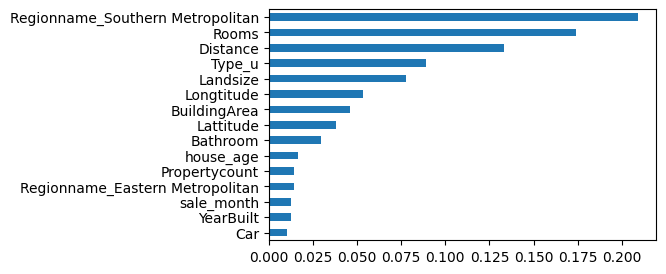

,0
Regionname_Southern Metropolitan,0.209
Rooms,0.174
Distance,0.133
Type_u,0.089
Landsize,0.078
Longtitude,0.053
BuildingArea,0.046
Lattitude,0.038
Bathroom,0.030
house_age,0.016


In [42]:
# Важливість ознак у лісу:
#  - у навченого лісу візьміть model.feature_importances_
#  - назви стовпців після One-Hot дістаньте через get_feature_names_out
#  - відсортуйте і подивіться топ ознак

ohe_names = rf_pipe.named_steps['prep'].named_transformers_['cat'] \
            .named_steps['ohe'].get_feature_names_out(cat_cols)

feat_names = list(num_cols) + list(ohe_names)
imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names) \
      .sort_values(ascending=False).head(15)

plt.figure(figsize=(5, 3))
imp[::-1].plot.barh()
plt.show()

imp.round(3)

## Прогноз (на автоматично заповнених даних)

In [43]:
example = X_test.iloc[[0]]
true_price = y_test.iloc[0]

pred_price = rf_pipe.predict(example)[0]

print(f'Прогноз: {pred_price:,.2f}')
print(f'Справжня ціна: {true_price:,.2f}')
print('-' * 10)
print(f'Error: {pred_price - true_price:,.2f}')
print(f'Error: {np.abs((pred_price - true_price) / true_price):,.2%}')

Прогноз: 2,176,722.50
Справжня ціна: 2,600,000.00
----------
Error: -423,277.50
Error: 16.28%


## розбір from sklearn.impute import SimpleImputer

In [44]:
from sklearn.impute import SimpleImputer
import numpy as np

X = [[25], [30], [np.nan], [35]]

# imputer = SimpleImputer(strategy='mean')  # for numeric
# imputer = SimpleImputer(strategy='median')  # for numeric
# imputer = SimpleImputer(strategy='most_frequent')  # ~ mode
imputer = SimpleImputer(strategy='constant', fill_value=10000)  # own value
X_filled = imputer.fit_transform(X)
X_filled

array([[   25.],
       [   30.],
       [10000.],
       [   35.]])

##Розбір скорочених даних (менше 50%, проте наповнені оригінально)

In [45]:
df_drop = df.copy()
df_drop = df_drop.dropna()
print("before drop:", df.shape)
print("ater drop:", df_drop.shape)
num = df_drop.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
ater drop: (5179, 21)


,Price
BuildingArea,0.492
Bathroom,0.469
Rooms,0.466
Bedroom2,0.443
YearBuilt,-0.297
Lattitude,-0.260
Distance,-0.255
Longtitude,0.217
Car,0.203
Propertycount,-0.020


In [46]:
fe_drop = df_drop.copy()
fe_drop['Date'] = pd.to_datetime(fe_drop["Date"], dayfirst=True)

# 1) частини дати продажу
#    - рік: fe["sale_year"] = fe["Date"].dt.year
#    - місяць: за аналогією дістаньте .dt.month
fe_drop["sale_year"] = fe_drop["Date"].dt.year
fe_drop["sale_month"] = fe_drop["Date"].dt.month

# 2) вік будинку на момент продажу
#    - це рік продажу мінус рік побудови (YearBuilt)
#    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan
fe_drop["age"] = fe_drop["sale_year"] - fe_drop['YearBuilt']
fe_drop.loc[fe_drop['age'] < 0, 'age'] = np.nan

# 3) прапорці наявності (пропуск як сигнал)
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
fe_drop["has_buildingarea"] = fe_drop["BuildingArea"].notna().astype(int)
fe_drop["has_yearbuilt"] = fe_drop["YearBuilt"].notna().astype(int)

# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
fe_drop["suburb_freq"] = fe_drop["Suburb"].map(fe_drop["Suburb"].value_counts())

# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
drop_cols = [
    'Bedroom2', 'Address', 'Suburb', 'Postcode',
    'Date', 'YearBuilt', 'SellerG', #'BuildingArea'
]
fe_drop = fe_drop.drop(columns=drop_cols)
fe_drop

,Rooms,Type,Price,Method,Distance,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,sale_year,sale_month,age,has_buildingarea,has_yearbuilt,suburb_freq
1,2,h,1035000.0,S,2.5,1.0,0.0,156.0,79.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0,2016,2,116.0,1,1,31
2,3,h,1465000.0,SP,2.5,2.0,0.0,134.0,150.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0,2017,3,117.0,1,1,31
4,4,h,1600000.0,VB,2.5,1.0,2.0,120.0,142.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0,2016,6,2.0,1,1,31
6,3,h,1876000.0,S,2.5,2.0,0.0,245.0,210.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0,2016,5,106.0,1,1,31
7,2,h,1636000.0,S,2.5,1.0,2.0,256.0,107.0,Yarra,-37.80600,144.99540,Northern Metropolitan,4019.0,2016,10,126.0,1,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12202,4,h,821000.0,S,16.5,3.0,2.0,544.0,264.0,Hume,-37.67841,144.87924,Northern Metropolitan,2474.0,2017,7,20.0,1,1,5
12203,3,h,635000.0,S,16.5,2.0,1.0,691.0,177.0,Hume,-37.68026,144.88468,Northern Metropolitan,2474.0,2017,7,42.0,1,1,5
12205,3,h,601000.0,S,35.5,2.0,1.0,972.0,149.0,Whittlesea,-37.51232,145.13282,Northern Victoria,2170.0,2017,7,21.0,1,1,1
12206,3,h,1050000.0,VB,6.8,1.0,0.0,179.0,115.0,Hobsons Bay,-37.86558,144.90474,Western Metropolitan,6380.0,2017,7,127.0,1,1,39


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій

# 1) ціль і ознаки
#    - y = ціна (стовпець Price)
#    - X = усе інше (приберіть Price)
y = fe_drop['Price']
X = fe_drop.drop(columns=['Price'])


# 2) поділіть стовпці на категорійні і числові
#    - cat_cols = [...]   # текстові: Type, Method, Regionname, CouncilArea
#    - num_cols = [...]   # решта числових (усе, що не в cat_cols)
cat_cols = ['Type', 'Method', 'Regionname', 'CouncilArea']
num_cols = [c for c in X.columns if c not in cat_cols]

# 3) опишіть підготовку через ColumnTransformer:
#    - для числових: SimpleImputer(strategy="median")
#    - для категорійних: спочатку SimpleImputer(strategy="most_frequent"),
#      потім OneHotEncoder(handle_unknown="ignore")
#    - підказка щодо структури:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy='most_frequent')),
        ("ohe", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


# 4) поділіть дані на train і test
#    - використайте train_test_split з test_size=0.2 і random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Numeric features:", num_cols)
print("Categories features:", cat_cols)

Train: 4143 | Test: 1036
Numeric features: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Lattitude', 'Longtitude', 'Propertycount', 'sale_year', 'sale_month', 'age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']
Categories features: ['Type', 'Method', 'Regionname', 'CouncilArea']


In [48]:
from sklearn.dummy import DummyRegressor                 # базова лінія
from sklearn.linear_model import LinearRegression        # проста модель
from sklearn.ensemble import RandomForestRegressor       # складніша модель
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Зручно зробити невелику функцію, що навчає модель і друкує метрики:
def evaluate(model, name):
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, {
        "model": name,
        "MAE": round(mean_absolute_error(y_test, pred)),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R2": round(r2_score(y_test, pred), 3)
    }

# Викличте evaluate по черзі:
#  - DummyRegressor(strategy="mean")            -> базова лінія
#  - LinearRegression()                         -> проста модель
#  - RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE) -> ліс
# Порівняйте результати: яка модель найкраща і чому?

_, r0 = evaluate(DummyRegressor(strategy="mean"), 'базова лінія (mean)')
_, r1 = evaluate(LinearRegression(), 'лінійна регресія')
rf_pipe, r2 = evaluate(
    RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Randon Forest'
)

pd.DataFrame([r0, r1, r2])

,model,MAE,RMSE,R2
0,базова лінія (mean),490911,721693,-0.000
1,лінійна регресія,251840,464514,0.586
2,Randon Forest,183784,392073,0.705


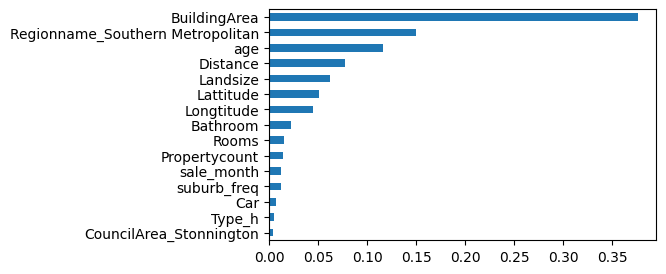

,0
BuildingArea,0.376
Regionname_Southern Metropolitan,0.150
age,0.116
Distance,0.077
Landsize,0.063
Lattitude,0.051
Longtitude,0.045
Bathroom,0.023
Rooms,0.015
Propertycount,0.014


In [49]:
ohe_names = rf_pipe.named_steps['prep'].named_transformers_['cat'] \
            .named_steps['ohe'].get_feature_names_out(cat_cols)

feat_names = list(num_cols) + list(ohe_names)
imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names) \
      .sort_values(ascending=False).head(15)

plt.figure(figsize=(5, 3))
imp[::-1].plot.barh()
plt.show()

imp.round(3)


## Прогноз на скорочених даних

In [50]:
example = X_test.iloc[[0]]
true_price = y_test.iloc[0]

pred_price = rf_pipe.predict(example)[0]

print(f'Прогноз: {pred_price:,.2f}')
print(f'Справжня ціна: {true_price:,.2f}')
print('-' * 10)
print(f'Error: {pred_price - true_price:,.2f}')
print(f'Error: {np.abs((pred_price - true_price) / true_price):,.2%}')

Прогноз: 2,307,240.00
Справжня ціна: 2,550,000.00
----------
Error: -242,760.00
Error: 9.52%
